In [1]:
import numpy as np, matplotlib.pyplot as plt

Solution to Question 1

In [2]:
#Part a

def target_distribution(x, mean, std_dev):
    return( np.exp( -(x - mean)**2 / (2*std_dev**2)) ) # this is not normalized as not needed

In [25]:
num_iterations = 5000
x0 = 0 #initial position
positions = np.zeros(num_iterations) #an array for storing position after every step in the run
bur_in_position = int(0.2*num_iterations)
positions[0] = x0
#although this last statement has no impact for this case, but is useful when automating the program
mean = 5; std_dev = 1
c = 0

#the below loop runs only for 4999 steps as the first step was initializing, i.e. when we set positions[0] = x0

for n in range(1, num_iterations):
    x_t = positions[n-1]
    x_new = x_t + np.random.normal(0, 1)
    alpha = min(1, target_distribution(x_new, mean, std_dev)/target_distribution(x_t, mean, std_dev))

    #now accepting or rejecting
    if np.random.rand()<alpha:
        positions[n] = x_new
        c+=1 #counting number of steps taken
    else:
        positions[n] = x_t

positions_after_burn_in = positions[bur_in_position:]

emp_mean = np.mean(positions_after_burn_in) #empirical mean
emp_std_dev = np.std(positions_after_burn_in) #empirical standard deviation

print('\n'+'='*60+'\n')
print(f"Empirical mean = {emp_mean:.3f}\n")
print(f"Empirical Standard Deviation = {emp_std_dev:.3f}\n")
print(f"True mean = {mean:.3f}\n")
print(f"True Standard Deviation = {std_dev:.3f}")
print('\n'+'='*60+'\n')



Empirical mean = 5.066

Empirical Standard Deviation = 0.983

True mean = 5.000

True Standard Deviation = 1.000




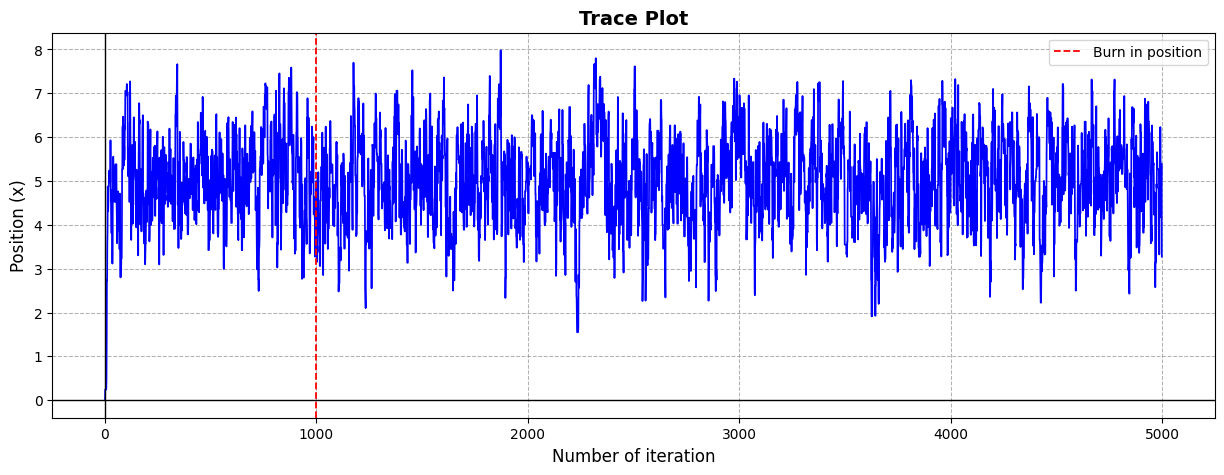

In [17]:
#Part b

fig = plt.figure(figsize = (15, 5))

plt.plot(positions, c = 'blue', lw = 1.25)
plt.axvline(bur_in_position, ls = '--', c = 'red', lw = 1.3, label = "Burn in position")
plt.title("Trace Plot", fontweight = 'bold', fontsize = 14)
plt.xlabel("Number of iteration", fontsize = 12)
plt.ylabel("Position (x)", fontsize = 12)
plt.axhline(0, c = 'black', lw = 1)
plt.axvline(0, c = 'black', lw = 1)
plt.grid(True, c = 'grey', ls = '--', lw = 0.75, alpha = 0.6)
plt.legend()
plt.show()

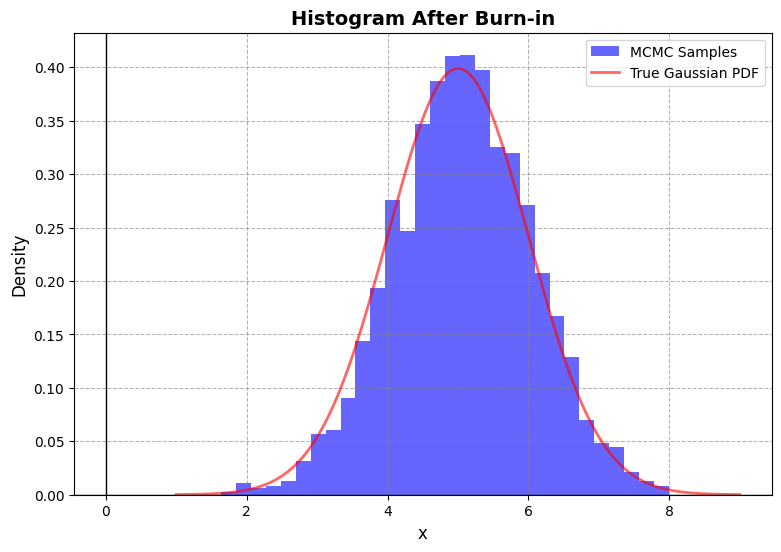

In [61]:
x_vals = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
true_pdf = (1 / (np.sqrt(2*np.pi)*std_dev)) * np.exp(-(x_vals - mean)**2 / (2*std_dev**2)) #equation of bell-curve

plt.figure(figsize=(9, 6))
plt.hist(positions_after_burn_in, bins=30, density=True, color = 'blue', alpha=0.6, label="MCMC Samples")
plt.plot(x_vals, true_pdf, 'r', lw=2, label="True Gaussian PDF", alpha = 0.6)
plt.title("Histogram After Burn-in", fontweight = 'bold', fontsize = 14)
plt.xlabel("x", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.axhline(0, c = 'black', lw = 1)
plt.axvline(0, c = 'black', lw = 1)
plt.grid(True, c = 'grey', ls = '--', lw = 0.75, alpha = 0.6)
plt.legend()
plt.show()

Solution to Question 2

In [26]:
#part a

def target_function2(x, lamda):
    if x<0:
        return(0)
    else:
        return(lamda*np.exp(-lamda*x))

In [27]:
def proposal_sample():
    return(np.random.exponential(scale = 1.0))

In [30]:
#probability distribution function for exponential(1) distribution
def proposal_pdf(Y):
    if Y >= 0:
        return(np.exp(-Y))
    else:
        return(0)

In [54]:
lamda = 0.5
num_iterations = 5000
x0 = 1.0
bur_in_position = int(0.2*num_iterations)

data = np.zeros(num_iterations)
data[0] = x0

#the below loop runs only for 4999 steps as the first step was initializing, i.e. when we set data[0] = x0

for i in range(1, num_iterations):
    x_t = data[i-1]
    Y = proposal_sample()
    x_new = x_t + Y

    if x_new <= 0:
        data[i] = x_t
    
    ratio_of_q = proposal_pdf(x_t - x_new) / proposal_pdf(x_new - x_t)
    alpha = min(1, (target_function2(x_new, lamda) / target_function2(x_t, lamda))*ratio_of_q)

    if np.random.rand()<alpha:
        data[i] = x_new
    else:
        data[i] = x_t


data_after_burn_in = data[bur_in_position:]

emp_mean_2 = np.mean(data_after_burn_in)
print('\n'+'='*60+'\n')
print(f"Empirical Mean = {emp_mean_2}\n")
print(f"True Mean = {1/lamda:.4f}")
print('\n'+'='*60+'\n')



Empirical Mean = 1.0

True Mean = 2.0000




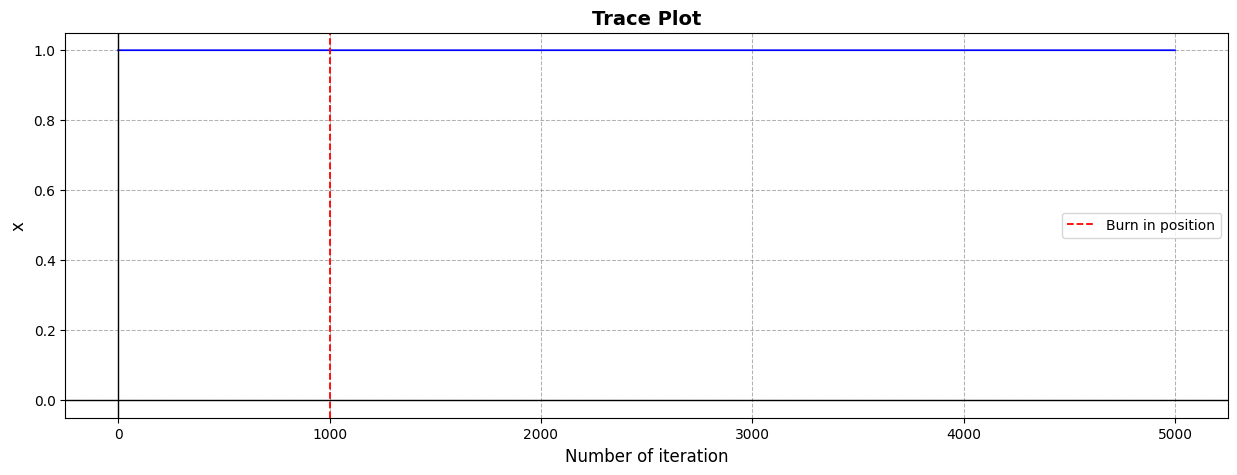

In [60]:
#part b

fig = plt.figure(figsize = (15, 5))

plt.plot(data, c = 'blue', lw = 1.25)
plt.axvline(bur_in_position, ls = '--', c = 'red', lw = 1.3, label = "Burn in position")
plt.title("Trace Plot", fontweight = 'bold', fontsize = 14)
plt.xlabel("Number of iteration", fontsize = 12)
plt.ylabel("x", fontsize = 12)
plt.axhline(0, c = 'black', lw = 1)
plt.axvline(0, c = 'black', lw = 1)
plt.grid(True, c = 'grey', ls = '--', lw = 0.75, alpha = 0.6)
plt.legend()
plt.show()

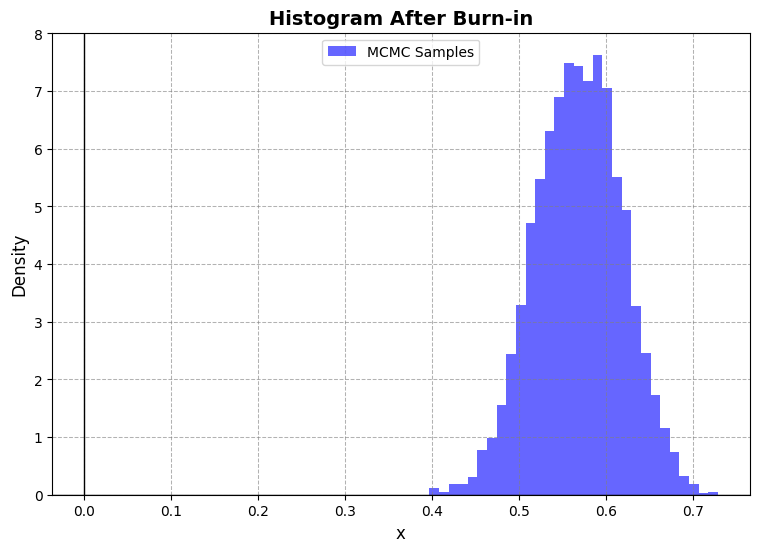

In [68]:
plt.figure(figsize=(9, 6))
plt.hist(data_after_burn_in, bins=30, density=True, color = 'blue', alpha=0.6, label="MCMC Samples")
plt.title("Histogram After Burn-in", fontweight = 'bold', fontsize = 14)
plt.xlabel("x", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.axhline(0, c = 'black', lw = 1)
plt.axvline(0, c = 'black', lw = 1)
plt.grid(True, c = 'grey', ls = '--', lw = 0.75, alpha = 0.6)
plt.legend()
plt.show()

In [63]:
"""
When I have an asymmetric proposal distribution it means that my jump from x to x' is more likely and easy with respect to jumps backwards. Without fixing, the algorithm will naturally drift toward the areas easier to reach, resulting in a bad result.
Also, the proposal ratio is acting like an adjustment. It compnsates for the imbalance and hence ensuring that the math is obeyed so that the simulation eventually converges to the target distribution
"""

"\nWhen I have an asymmetric proposal distribution it means that my jump from x to x' is more likely and easy with respect to jumps backwards. Without fixing, the algorithm will naturally drift toward the areas easier to reach, resulting in a bad result.\nAlso, the proposal ratio is acting like an adjustment. It compnsates for the imbalance and hence ensuring that the math is obeyed so that the simulation eventually converges to the target distribution\n"

Solution to Question 3

In [64]:
#part a

num_flips = 100
true_p = 0.6

heads = np.random.binomial(num_flips, true_p)
tails = num_flips - heads

def posterior_log(p):
    if p<=0 or p>=1:
        return(-np.inf)
    return(heads*np.log(p) + tails*np.log(1-p))

In [65]:
num_iterations = 10000
proposal_std = 0.1
burn_in_position = int(0.2*num_iterations)

data = np.zeros(num_iterations)
data[0] = 0.5 #this is our initial guess

#the below loop runs only for 4999 steps as the first step was initializing, i.e. when we set data[0] = x0

for i in range(1, num_iterations):
    p_t = data[i-1]
    p_new = p_t + np.random.normal(0, proposal_std)

    alpha = min(1, np.exp(posterior_log(p_new) - posterior_log(p_t)))

    if np.random.rand()<alpha:
        data[i] = p_new
    else:
        data[i] = p_t

data_after_burn_in = data[bur_in_position:]
post_mean = np.mean(data_after_burn_in)
credibal_interval = np.percentile(data_after_burn_in, [2.5, 97.5])

print('\n'+'='*60+'\n')
print(f"Posterior Mean = {post_mean}\n")
print(f"95% Creibal Interval = {credibal_interval}\n")
print(f"True p = {true_p}")
print('\n'+'='*60+'\n')



Posterior Mean = 0.5684885529053777

95% Creibal Interval = [0.47130911 0.66332816]

True p = 0.6




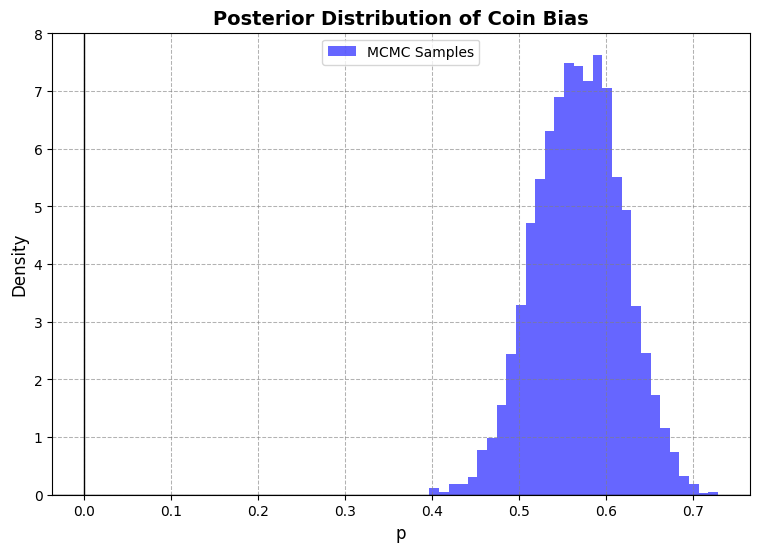

In [69]:
#part b

plt.figure(figsize=(9, 6))
plt.hist(data_after_burn_in, bins=30, density=True, color = 'blue', alpha=0.6, label="MCMC Samples")
plt.title("Posterior Distribution of Coin Bias", fontweight = 'bold', fontsize = 14)
plt.xlabel("p", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.axhline(0, c = 'black', lw = 1)
plt.axvline(0, c = 'black', lw = 1)
plt.grid(True, c = 'grey', ls = '--', lw = 0.75, alpha = 0.6)
plt.legend()
plt.show()

In [70]:
"""
The algorithm actually worked, both our average result and the likely range we calculated inclluded the real value of 0.6, meaning the math successfully figured out how the coin was biased
"""

'\nThe algorithm actually worked, both our average result and the likely range we calculated inclluded the real value of 0.6, meaning the math successfully figured out how the coin was biased\n'